In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

### Función Análisis Exploratorio de Datos

In [ ]:
 # Funcion para un Análisis Exploratorio inicial de los datos
def exploracion_inicial(df, tipo=None):
    print("¿Cuántas filas y columnas hay en el conjunto de datos?")
    num_filas, num_columnas = df.shape
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    if tipo == 'simple':
        print("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display(df.head(2))
    else:
        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n=5))

        print("¿Cuáles son las columnas del conjunto de datos?")
        print("\n".join(f"\t- {col}" for col in df.columns))

        print("¿Cuál es el tipo de datos de cada columna?")
        print(df.dtypes)

        print("¿Cuántas columnas hay de cada tipo de datos?")
        print(df.dtypes.value_counts())

        print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
        df.info()

        print("¿Cuántos valores únicos tiene cada columna?")
        print(df.nunique())

        print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
        display(df.describe(include='all').fillna(''))

        print("¿Hay valores nulos en el conjunto de datos?")
        print(df.isnull().sum())

        print("¿Cuál es la proporción de valores nulos en cada columna?")
        print((df.isnull().sum() / len(df) * 100).round(2))

    print('#' * 90)

### Carga de Datos

In [ ]:
# Orders Dataset
df_orders = pd.read_csv("/content/olist_orders_dataset.csv")



### Análisis Exploratorio de los Datos (EDA)

#### Orders Dataset

In [ ]:
exploracion_inicial(df_orders)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 99,441 filas y 8 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


¿Cuáles son las últimas cinco filas del conjunto de datos?


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
91510,804e0b86e8fe8f4b319d850c87dd79bd,a4844df7aea664c484381063cc7c5a05,delivered,2017-07-11 22:50:05,2017-07-12 00:35:16,2017-07-12 17:32:46,2017-07-31 14:33:40,2017-07-24 00:00:00
12069,788c740eb8e85e60ba673175e96f3a76,87e0d8c98901635a02de3d22ae4c2e84,delivered,2017-11-27 11:55:16,2017-11-27 12:14:48,2017-11-29 22:24:47,2017-12-01 17:42:57,2017-12-11 00:00:00
86281,de05dd73ee1b5a964eaa56f814c49851,a5f97dadc879a0cba20bf9650b1bd888,delivered,2017-01-21 18:17:15,2017-01-21 18:30:09,2017-01-23 18:14:17,2017-01-26 15:18:51,2017-03-08 00:00:00
94204,505e3b83ecc630a2507a9d9c8bfedd8b,234b8c7443c22633e616ec258dbb68c8,delivered,2017-10-05 14:48:13,2017-10-06 02:07:11,2017-10-09 22:46:31,2017-10-27 09:38:49,2017-11-03 00:00:00
28175,438b46304b3217ea878c63aeb5b98f5d,21831634eda702776bee4cbd95446d82,delivered,2018-07-03 18:15:23,2018-07-05 16:40:34,2018-07-04 11:51:00,2018-07-10 18:27:47,2018-07-27 00:00:00


¿Cuáles son las columnas del conjunto de datos?
	- order_id
	- customer_id
	- order_status
	- order_purchase_timestamp
	- order_approved_at
	- order_delivered_carrier_date
	- order_delivered_customer_date
	- order_estimated_delivery_date
¿Cuál es el tipo de datos de cada columna?
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
¿Cuántas columnas hay de cada tipo de datos?
object    8
Name: count, dtype: int64
¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


¿Hay valores nulos en el conjunto de datos?
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
¿Cuál es la proporción de valores nulos en cada columna?
order_id                         0.00
customer_id                      0.00
order_status                     0.00
order_purchase_timestamp         0.00
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
order_estimated_delivery_date    0.00
dtype: float64
##########################################################################################


#### Comprobación de Duplicados

In [ ]:
df_orders.duplicated().sum()

np.int64(0)

No existen por tanto valores duplicados en nuestro DataFrame

#### Formato Fecha

In [ ]:
df_orders['order_approved_at'] = pd.to_datetime(df_orders['order_approved_at'])
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])



In [ ]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


#### Comprobación de Nulos

In [ ]:
df_orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Existen valores nulos en nuestras variables de order_approved_at (16%), order_delivered_carrier_date (17.9%), order_delivered_customer_date (29.8%). Podríamos imputar los nulos con una fecha estandar, por ejemplo 1960-01-01, pero esto desvirtuaría los cálculos posteriores. Al haber convertido a formato datetime, Pandas automaticamente gestiona los nulos como Not A Time (NaT), excluyéndolos de los cálculos.

#### Creación de Nuevas Variables

Dias transcurridos entre la fecha de compra y la fecha de aprobacion

In [ ]:
df_orders['purchase_to_approval_days'] = (df_orders['order_approved_at'] - df_orders['order_purchase_timestamp']).dt.days

In [ ]:
# Moda
df_orders['purchase_to_approval_days'].mode()
print(f"Moda: {df_orders['purchase_to_approval_days'].mode()[0]} días")
# Media
df_orders['purchase_to_approval_days'].mean()
print(f"Media: {df_orders['purchase_to_approval_days'].mean():.2f} días")

Moda: 0.0 días
Media: 0.27 días


Dias transcurridos entre la fecha de la aprobacion y la entrega al transportista

In [ ]:
df_orders['approval_to_carrier_days'] = (df_orders['order_delivered_carrier_date'] - df_orders['order_approved_at']).dt.days

In [ ]:
# Moda
df_orders['approval_to_carrier_days'].mode()
print(f"Moda: {df_orders['approval_to_carrier_days'].mode()[0]} días")
# Media
df_orders['approval_to_carrier_days'].mean()
print(f"Media: {df_orders['approval_to_carrier_days'].mean():.2f} días")

Moda: 0.0 días
Media: 2.30 días


Dias transcurridos entre la entrega al transportista y la entrega al cliente

In [ ]:
df_orders['carrier_to_customer_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_delivered_carrier_date']).dt.days

In [ ]:
# Moda
df_orders["carrier_to_customer_days"].mode()
print(f"Moda: {df_orders['carrier_to_customer_days'].mode()[0]} días")
# Media
df_orders["carrier_to_customer_days"].mean()
print(f"Media: {df_orders['carrier_to_customer_days'].mean():.2f} días")

Moda: 6.0 días
Media: 8.88 días


Dias transcurridos entre la fecha de compra y la entrega al cliente

In [ ]:
df_orders['purchase_to_delivery_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

In [ ]:
# Moda
df_orders['purchase_to_delivery_days'].mode()
print(f"Moda: {df_orders['purchase_to_delivery_days'].mode()[0]} días")
# Media
df_orders['purchase_to_delivery_days'].mean()
print(f"Media: {df_orders['purchase_to_delivery_days'].mean():.2f} días")

Moda: 7.0 días
Media: 12.09 días


Diferencia entre la entrega prevista y la real

In [ ]:
df_orders['delay_vs_estimated_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']).dt.days

# Moda
df_orders["delay_vs_estimated_days"].mode()
print(f"Moda: {df_orders['delay_vs_estimated_days'].mode()[0]} días")
# Media
df_orders["delay_vs_estimated_days"].mean()
print(f"Media: {df_orders['delay_vs_estimated_days'].mean():.2f} días")

Moda: -14.0 días
Media: -11.88 días


# Representaciones Graficas

#### Distribución por Estado de Pedido

<ipython-input-26-7340728a6199>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  p = sns.countplot(x='order_status', data=df_orders, palette="Spectral")


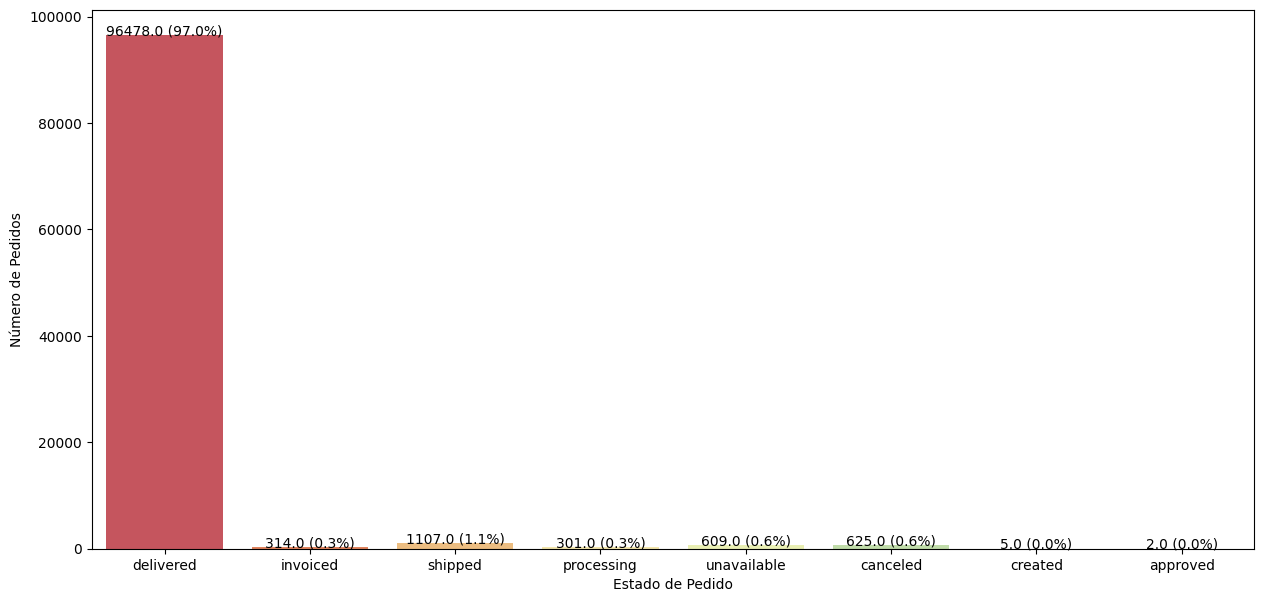

In [ ]:
# Representamos la cantidad de pedidos por Estados
plt.figure(figsize=(15, 7))
p = sns.countplot(x='order_status', data=df_orders, palette="Spectral")
p.set(xlabel="Estado de Pedido", ylabel="Número de Pedidos")
n = len(df_orders)

for k in p.patches:
    height = k.get_height()
    percentage = height / n
    p.text(
        k.get_x() + k.get_width() / 2.,
        height,
        f'{height} ({percentage:.1%})',
        ha="center"
    )

#### Pedidos por Mes

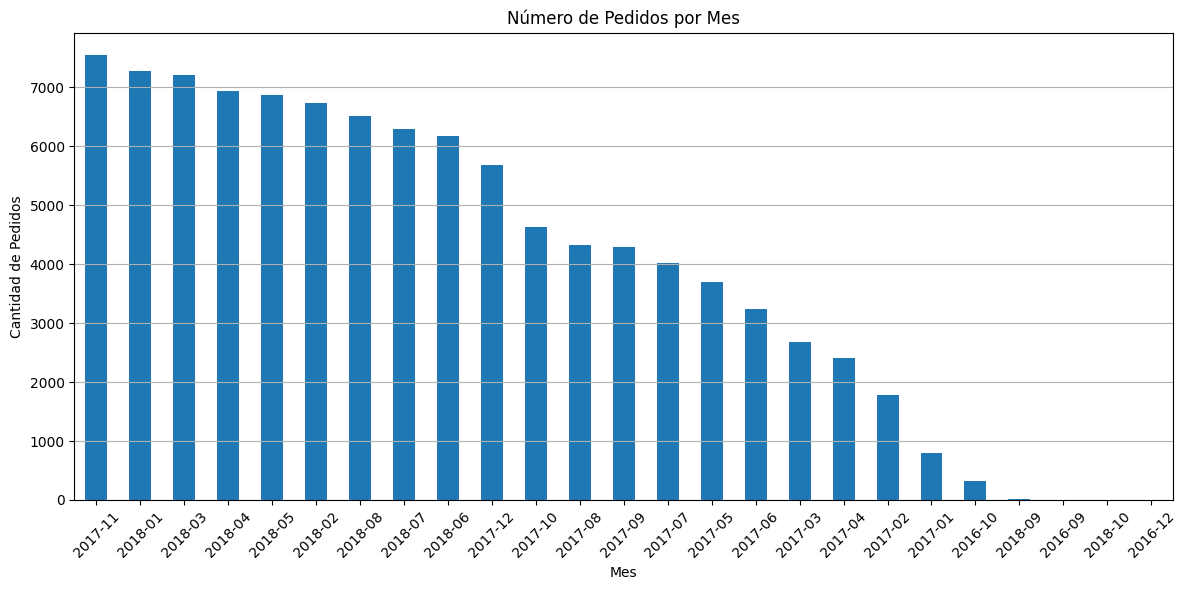

In [ ]:
# Extraemos el mes de order_purchase_timestamp
df_orders["order_month"] = df_orders["order_purchase_timestamp"].dt.to_period("M")

# Agrupamos por Mes y hacemos un Count
monthly_orders = df_orders.groupby("order_month")["order_id"].count()
monthly_orders = monthly_orders.sort_values(ascending=False)

# Convertimos a String el índice
monthly_orders.index = monthly_orders.index.astype(str)

# Representación Gráfico de Barras de forma Descendente
plt.figure(figsize=(12, 6))
monthly_orders.plot(kind="bar")
plt.title("Número de Pedidos por Mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de Pedidos")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Clasificación Pedidos según Fecha Entrega

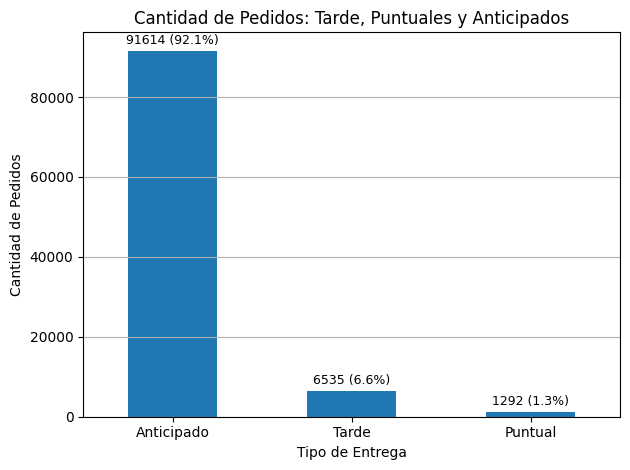

In [ ]:

conditions_count = df_orders['delay_vs_estimated_days'].apply(
    lambda x: 'Tarde' if x > 0 else ('Puntual' if x == 0 else 'Anticipado')
).value_counts()


ax = conditions_count.plot(kind='bar')


plt.title('Cantidad de Pedidos: Tarde, Puntuales y Anticipados')
plt.xlabel('Tipo de Entrega')
plt.ylabel('Cantidad de Pedidos')
plt.xticks(rotation=0)
plt.grid(axis='y')


total = conditions_count.sum()
for i, value in enumerate(conditions_count):
    percentage = (value / total) * 100
    plt.text(i, value + total * 0.01, f'{value} ({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### Proporción (%) de Pedidos según Fecha de Entrega

delay_vs_estimated_days
Anticipado    0.921290
Tarde         0.065717
Puntual       0.012993
Name: count, dtype: float64


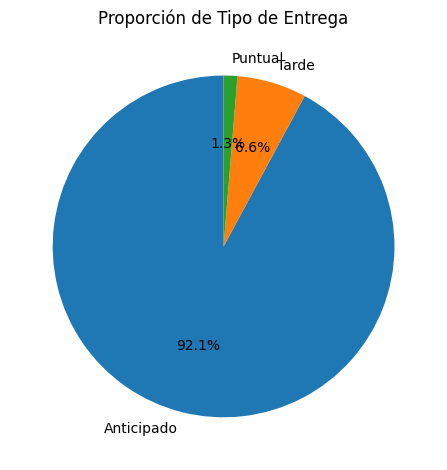

In [ ]:
conditions_ratio = conditions_count / conditions_count.sum()
print(conditions_ratio)

conditions_ratio.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Proporción de Tipo de Entrega')
plt.ylabel('')  # Oculta la etiqueta de eje Y
plt.tight_layout()
plt.show()

### TO CSV

In [ ]:
df_orders.to_csv('orders_clean.csv', index=False)
